In [7]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [8]:
df = pd.read_csv(r'C:\Users\monse\Walmart\Walmart_Sales.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [9]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [10]:
# 1. Primero aseguras que la columna sea interpretada como objeto de fecha (datetime)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# 2. Extraes los componentes numéricos individuales
df['Year'] = df['Date'].dt.year          # Año: 2010, 2011, 2012
df['Month'] = df['Date'].dt.month        # Mes: 1 al 12
df['Day'] = df['Date'].dt.day            # Día del mes: 1 al 31
df['Week_of_Year'] = df['Date'].dt.isocalendar().week  # Semana del año: 1 al 52

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Day           6435 non-null   int32         
 11  Week_of_Year  6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[us](1), float64(5), int32(3), int64(2)
memory usage: 509.1 KB


In [12]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Week_of_Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5,9


In [13]:
# Suponiendo que ya extrajiste las características de la fecha y tienes tu X
# X = df.drop(columns=['Weekly_Sales', 'Date'])

# 1. Definimos qué columnas van a qué proceso
features_a_escalar = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# 2. Creamos el transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_a_escalar)
    ],
    remainder='passthrough' # Esto deja las demás columnas (Holiday_Flag, Store, etc.) intactas
)

In [14]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Week_of_Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5,9


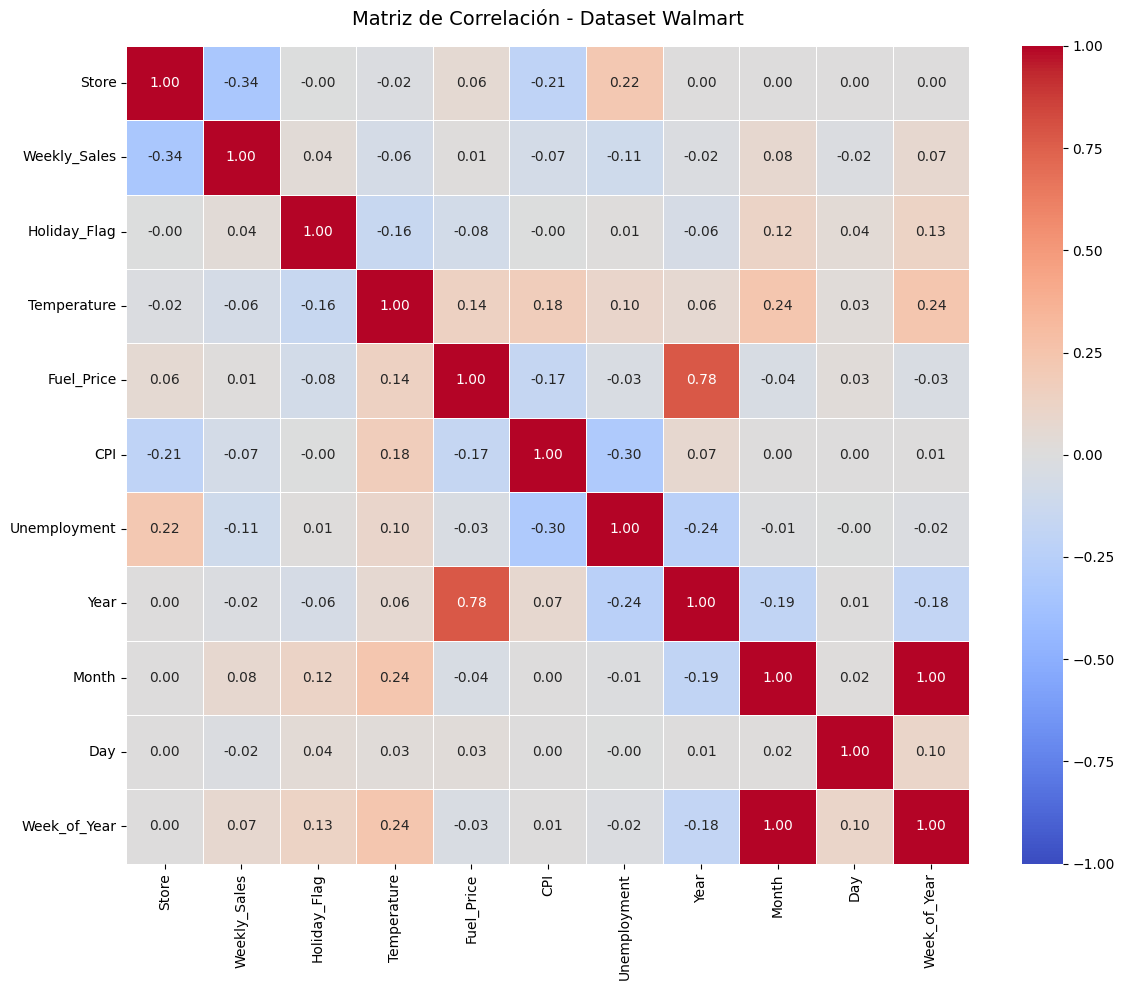

In [15]:
# Configurar el tamaño de la figura
plt.figure(figsize=(12, 10))

# Definimos las columnas que no aportan a una correlación numérica lineal directa
# Excluimos 'Date' (por ser texto/objeto)
columnas_a_excluir = ['Date']

# Calculamos la matriz excluyendo la fecha y asegurando solo valores numéricos
matriz_corr = df.drop(columns=columnas_a_excluir, errors='ignore').corr(numeric_only=True)

# Dibujar el mapa de calor (Heatmap)
sns.heatmap(
    matriz_corr, 
    annot=True,          # Muestra los valores numéricos dentro de los cuadros
    fmt=".2f",           # Limita a 2 decimales
    cmap="coolwarm",     # Escala de colores (azul frío para negativo, rojo cálido para positivo)
    linewidths=0.5,      # Línea de separación entre cuadros
    vmin=-1, vmax=1      # Forzar los límites de la correlación de -1 a 1
)

# Configuración del título y diseño limpio
plt.title("Matriz de Correlación - Dataset Walmart", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [16]:
# Calcular la correlación de cada característica con la variable objetivo (Weekly_Sales)
# Excluimos de las filas la propia variable objetivo y 'Date' si aún está en el dataframe
correlations = df.corr(numeric_only=True)['Weekly_Sales'].drop(['Weekly_Sales', 'Date'], errors='ignore')

# Aplicar valor absoluto para medir la fuerza de la relación (importancia lineal)
absolute_correlations = correlations.abs()

# Ordenar de mayor a menor importancia (descendente) y tomar las 5 principales
sorted_features = absolute_correlations.sort_values(ascending=False).head(5)

print("Importancia de las características (por correlación absoluta con Weekly_Sales):")
print(sorted_features)

Importancia de las características (por correlación absoluta con Weekly_Sales):
Store           0.335332
Unemployment    0.106176
Month           0.076143
Week_of_Year    0.074211
CPI             0.072634
Name: Weekly_Sales, dtype: float64


In [17]:
# 1. Definimos la variable objetivo (Target) - Ventas en dólares
y = df['Weekly_Sales']

# 2. Lista de exclusión de columnas para X
# Quitamos 'Weekly_Sales' (el target) y 'Date' (porque es texto y no entra directo al modelo)
columnas_a_excluir = ['Weekly_Sales', 'Date']

# Creamos la matriz de características X (predictores)
X = df.drop(columns=columnas_a_excluir, errors='ignore')

# 3. Configuramos el modelo de REGRESIÓN
rf_regresor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 4. Ejecutamos RFECV con métrica de regresión (R² o Error Absoluto Medio Negativo)
# Usamos cv=5 (Cross-Validation de 5 pliegues)
rfecv = RFECV(estimator=rf_regresor, step=1, cv=5, scoring='r2')
rfecv = rfecv.fit(X, y)

# --- RESULTADOS ---
print('Características analizadas en X:', list(X.columns))
print('Características seleccionadas (True = Excelente aporte, False = Descartada):', rfecv.support_)
print('Ranking de características (El 1 significa que es óptima):', rfecv.ranking_)
print('Número óptimo de características:', rfecv.n_features_)

# Columnas finales elegidas por el algoritmo para predecir las ventas
columnas_optimas = X.columns[rfecv.support_]
print('\nLas mejores columnas para predecir las Ventas Semanales son:', list(columnas_optimas))

Características analizadas en X: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'Week_of_Year']
Características seleccionadas (True = Excelente aporte, False = Descartada): [ True False  True  True  True  True  True  True  True  True]
Ranking de características (El 1 significa que es óptima): [1 2 1 1 1 1 1 1 1 1]
Número óptimo de características: 9

Las mejores columnas para predecir las Ventas Semanales son: ['Store', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'Week_of_Year']


In [18]:
columnas_seleccionadas = ['Store', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'Week_of_Year']

X = df[columnas_seleccionadas]
y = df['Weekly_Sales']

kf = KFold(n_splits=7, shuffle=True, random_state=42)

lista_r2 = []
lista_mae = []
filas_tabla = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    modelo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)
    r2 = r2_score(y_test, predicciones)
    mae = mean_absolute_error(y_test, predicciones)
    lista_r2.append(r2)
    lista_mae.append(mae)
    filas_tabla.append({
        'Corrida': f'Corrida_{i+1}',
        'R2 (Coeficiente Determinacion)': round(r2, 4),
        'MAE (Error Absoluto Medio)': round(mae, 2)
    })
promedio_r2 = np.mean(lista_r2)
promedio_mae = np.mean(lista_mae)
filas_tabla.append({
    'Corrida': 'PROMEDIO',
    'R2 (Coeficiente Determinacion)': round(promedio_r2, 4),
    'MAE (Error Absoluto Medio)': round(promedio_mae, 2)
})

df_resultados = pd.DataFrame(filas_tabla)
df_resultados.to_csv('resultados_validacion_cruzada.csv', index=False)
df_resultados

,Corrida,R2 (Coeficiente Determinacion),MAE (Error Absoluto Medio)
0,Corrida_1,0.9655,53198.32
1,Corrida_2,0.9655,52018.12
2,Corrida_3,0.9690,53603.55
3,Corrida_4,0.9681,52164.08
4,Corrida_5,0.9757,48740.82
5,Corrida_6,0.9724,50058.02
6,Corrida_7,0.9748,48361.67
7,PROMEDIO,0.9701,51163.51


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Entrenar el modelo
modelo_unico = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_unico.fit(X_train, y_train)

# 4. Realizar predicciones sobre el set de prueba
predicciones = modelo_unico.predict(X_test)

# 5. Calcular los Residuos (Valor Real - Valor Predicho)
residuos = y_test - predicciones

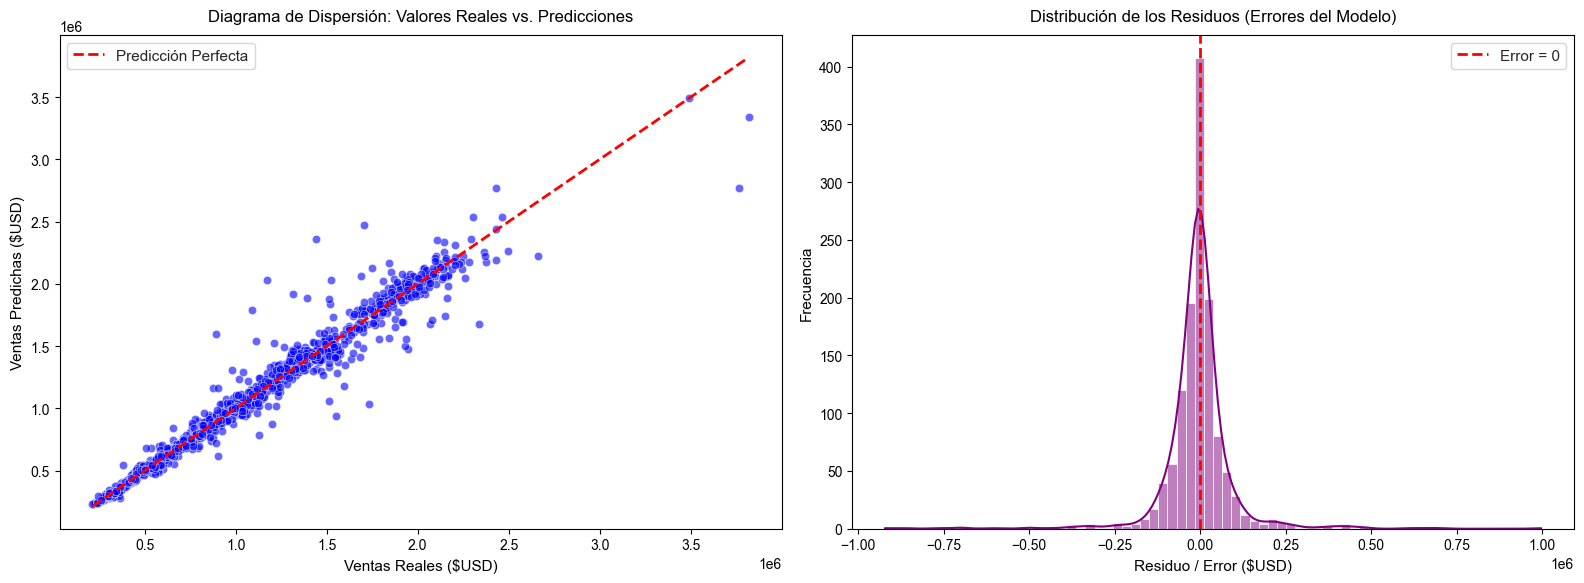

Métricas de esta corrida única:
R² (Coeficiente de Determinación): 0.9649
MAE (Error Absoluto Medio): $54,220.84


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# GRÁFICO 1: Diagrama de Dispersión (Reales vs Predichos)
sns.scatterplot(x=y_test, y=predicciones, alpha=0.6, color='blue', ax=axes[0])
limites = [y_test.min(), y_test.max()]
axes[0].plot(limites, limites, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')
axes[0].set_title('Diagrama de Dispersión: Valores Reales vs. Predicciones', fontsize=12, pad=10)
axes[0].set_xlabel('Ventas Reales ($USD)', fontsize=11)
axes[0].set_ylabel('Ventas Predichas ($USD)', fontsize=11)
axes[0].legend()

# GRÁFICO 2: Distribución de Residuos
sns.histplot(residuos, kde=True, color='purple', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[1].set_title('Distribución de los Residuos (Errores del Modelo)', fontsize=12, pad=10)
axes[1].set_xlabel('Residuo / Error ($USD)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

# Imprimir métricas rápidas
print(f"Métricas de esta corrida única:")
print(f"R² (Coeficiente de Determinación): {r2_score(y_test, predicciones):.4f}")
print(f"MAE (Error Absoluto Medio): ${mean_absolute_error(y_test, predicciones):,.2f}")

In [21]:
import joblib

joblib.dump(modelo_unico, 'walmart_model.pkl')

['walmart_model.pkl']